In [13]:
# File 1
from google.colab import files
uploaded = files.upload()

Saving iris (1) (1).csv to iris (1) (1) (1).csv


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset (assuming 'iris (1) (1).csv' is the selected file)
# The file path comes from the user selection, so we need to use the exact path.
file_path = '/content/iris (1) (1).csv'
df = pd.read_csv(file_path)

# Display the first 5 rows to confirm loading
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [15]:
# Separate features (X) and target (y)
# Assuming 'species' is the target column
X = df.drop('species', axis=1)
y = df['species']

# Encode the target variable if it's categorical (e.g., 'Iris-setosa' to 0)
# This is typically done if not already in numerical format
if y.dtype == 'object':
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y = le.fit_transform(y)
    print("Target labels encoded.")
    print("Original species names:", le.classes_)

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Target labels encoded.
Original species names: ['setosa' 'versicolor' 'virginica']
X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


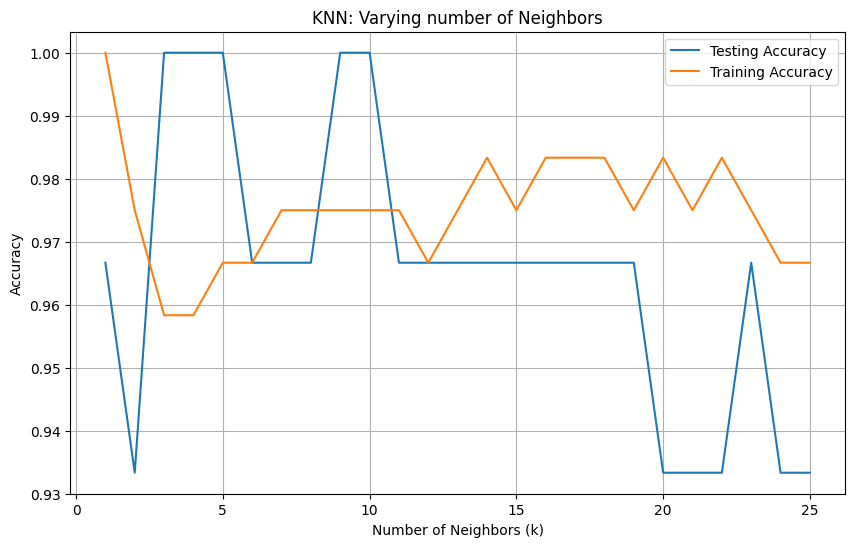

Optimal k value: 3
Maximum test accuracy for optimal k: 1.0000


In [16]:
neighbors = np.arange(1, 26) # Test k from 1 to 25
train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

# Loop over K values
for i, k in enumerate(neighbors):
    # Setup a KNN Classifier with k neighbors
    knn = KNeighborsClassifier(n_neighbors=k)

    # Fit the model
    knn.fit(X_train, y_train)

    # Compute accuracy on the training set
    train_accuracy[i] = knn.score(X_train, y_train)

    # Compute accuracy on the test set
    test_accuracy[i] = knn.score(X_test, y_test)

# Plotting the train and test accuracies for different k values
plt.figure(figsize=(10, 6))
plt.title('KNN: Varying number of Neighbors')
plt.plot(neighbors, test_accuracy, label='Testing Accuracy')
plt.plot(neighbors, train_accuracy, label='Training Accuracy')
plt.legend()
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Find the optimal k based on test accuracy
optimal_k_index = np.argmax(test_accuracy)
optimal_k = neighbors[optimal_k_index]
max_test_accuracy = test_accuracy[optimal_k_index]

print(f"Optimal k value: {optimal_k}")
print(f"Maximum test accuracy for optimal k: {max_test_accuracy:.4f}")

In [17]:
# Initialize KNN classifier with the optimal k value
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)

# Train the model
knn_optimal.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn_optimal.predict(X_test)

# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score on Test Data: {accuracy:.4f}")

# Display confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(cm, index=['Actual 0', 'Actual 1', 'Actual 2'], columns=['Predicted 0', 'Predicted 1', 'Predicted 2']))

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score on Test Data: 1.0000

Confusion Matrix:


,Predicted 0,Predicted 1,Predicted 2
Actual 0,10,0,0
Actual 1,0,10,0
Actual 2,0,0,10



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [18]:
# File 2
from google.colab import files
uploaded = files.upload()

Saving diabetes (1).csv to diabetes (1) (1).csv


In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the diabetes dataset
file_path_diabetes = '/content/diabetes (1).csv'
df_diabetes = pd.read_csv(file_path_diabetes)

print("First 5 rows of the diabetes dataset:")
display(df_diabetes.head())

print("\nInfo about the diabetes dataset:")
df_diabetes.info()

First 5 rows of the diabetes dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Info about the diabetes dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [20]:
# Separate features (X) and target (y)
X_diabetes = df_diabetes.drop('Outcome', axis=1)
y_diabetes = df_diabetes['Outcome']

# Split the data into training and testing sets (80% training, 20% testing)
X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(X_diabetes, y_diabetes, test_size=0.20, random_state=42, stratify=y_diabetes)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train_scaled_diabetes = scaler.fit_transform(X_train_diabetes)
X_test_scaled_diabetes = scaler.transform(X_test_diabetes)

print(f"X_train_scaled shape: {X_train_scaled_diabetes.shape}")
print(f"X_test_scaled shape: {X_test_scaled_diabetes.shape}")
print(f"y_train shape: {y_train_diabetes.shape}")
print(f"y_test shape: {y_test_diabetes.shape}")

X_train_scaled shape: (614, 8)
X_test_scaled shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)


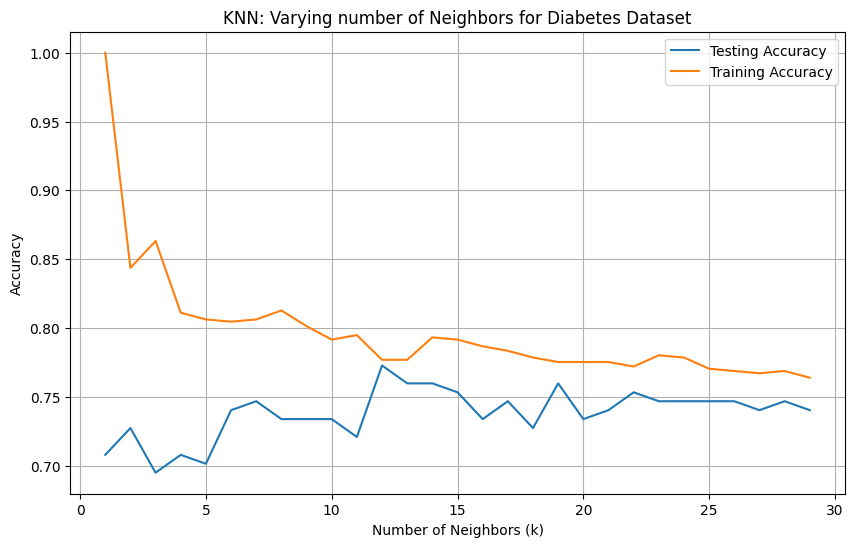

Optimal k value for Diabetes dataset: 12
Maximum test accuracy for optimal k: 0.7727


In [21]:
neighbors_diabetes = np.arange(1, 30) # Test k from 1 to 29
train_accuracy_diabetes = np.empty(len(neighbors_diabetes))
test_accuracy_diabetes = np.empty(len(neighbors_diabetes))

# Loop over K values
for i, k in enumerate(neighbors_diabetes):
    # Setup a KNN Classifier with k neighbors
    knn_diabetes = KNeighborsClassifier(n_neighbors=k)

    # Fit the model on scaled training data
    knn_diabetes.fit(X_train_scaled_diabetes, y_train_diabetes)

    # Compute accuracy on the scaled training set
    train_accuracy_diabetes[i] = knn_diabetes.score(X_train_scaled_diabetes, y_train_diabetes)

    # Compute accuracy on the scaled test set
    test_accuracy_diabetes[i] = knn_diabetes.score(X_test_scaled_diabetes, y_test_diabetes)

# Plotting the train and test accuracies for different k values
plt.figure(figsize=(10, 6))
plt.title('KNN: Varying number of Neighbors for Diabetes Dataset')
plt.plot(neighbors_diabetes, test_accuracy_diabetes, label='Testing Accuracy')
plt.plot(neighbors_diabetes, train_accuracy_diabetes, label='Training Accuracy')
plt.legend()
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Find the optimal k based on test accuracy
optimal_k_index_diabetes = np.argmax(test_accuracy_diabetes)
optimal_k_diabetes = neighbors_diabetes[optimal_k_index_diabetes]
max_test_accuracy_diabetes = test_accuracy_diabetes[optimal_k_index_diabetes]

print(f"Optimal k value for Diabetes dataset: {optimal_k_diabetes}")
print(f"Maximum test accuracy for optimal k: {max_test_accuracy_diabetes:.4f}")

In [22]:
# Initialize KNN classifier with the optimal k value for the diabetes dataset
knn_optimal_diabetes = KNeighborsClassifier(n_neighbors=optimal_k_diabetes)

# Train the model on the scaled training data
knn_optimal_diabetes.fit(X_train_scaled_diabetes, y_train_diabetes)

# Make predictions on the scaled test set
y_pred_diabetes = knn_optimal_diabetes.predict(X_test_scaled_diabetes)

# Calculate accuracy score
accuracy_diabetes = accuracy_score(y_test_diabetes, y_pred_diabetes)
print(f"Accuracy Score on Test Data (Diabetes): {accuracy_diabetes:.4f}")

# Display confusion matrix
print("\nConfusion Matrix (Diabetes):")
cm_diabetes = confusion_matrix(y_test_diabetes, y_pred_diabetes)
display(pd.DataFrame(cm_diabetes, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# Display classification report
print("\nClassification Report (Diabetes):")
print(classification_report(y_test_diabetes, y_pred_diabetes))

Accuracy Score on Test Data (Diabetes): 0.7727

Confusion Matrix (Diabetes):


,Predicted 0,Predicted 1
Actual 0,88,12
Actual 1,23,31



Classification Report (Diabetes):
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       100
           1       0.72      0.57      0.64        54

    accuracy                           0.77       154
   macro avg       0.76      0.73      0.74       154
weighted avg       0.77      0.77      0.77       154



In [23]:
# File 3
from google.colab import files
uploaded = files.upload()

Saving heart (1).csv to heart (1).csv


In [24]:
import pandas as pd

# Define the file path for the heart disease dataset
file_path_heart = '/content/heart (1).csv'

# Load the dataset into a pandas DataFrame
df_heart = pd.read_csv(file_path_heart)

print("First 5 rows of the heart disease dataset:")
display(df_heart.head())

print("\nInfo about the heart disease dataset:")
df_heart.info()

First 5 rows of the heart disease dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



Info about the heart disease dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Separate features (X) and target (y)
X_heart = df_heart.drop('target', axis=1)
y_heart = df_heart['target']

# 2. Identify categorical features and apply one-hot encoding
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Apply one-hot encoding to the categorical features in X_heart
X_heart = pd.get_dummies(X_heart, columns=categorical_features, drop_first=True)

print("Features after one-hot encoding:")
display(X_heart.head())

# 3. Split the data into training and testing sets
X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split(X_heart, y_heart, test_size=0.20, random_state=42, stratify=y_heart)

# 4. Initialize StandardScaler and scale the features
scaler_heart = StandardScaler()

# Fit on training data and transform both training and testing data
X_train_scaled_heart = scaler_heart.fit_transform(X_train_heart)
X_test_scaled_heart = scaler_heart.transform(X_test_heart)

# 5. Print the shapes of the resulting sets
print(f"\nX_train_scaled_heart shape: {X_train_scaled_heart.shape}")
print(f"X_test_scaled_heart shape: {X_test_scaled_heart.shape}")
print(f"y_train_heart shape: {y_train_heart.shape}")
print(f"y_test_heart shape: {y_test_heart.shape}")

Features after one-hot encoding:


,age,trestbps,chol,thalach,oldpeak,sex_1,cp_1,cp_2,cp_3,fbs_1,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,63,145,233,150,2.3,True,False,False,True,True,...,False,False,False,False,False,False,False,True,False,False
1,37,130,250,187,3.5,True,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
2,41,130,204,172,1.4,False,True,False,False,False,...,False,False,True,False,False,False,False,False,True,False
3,56,120,236,178,0.8,True,True,False,False,False,...,False,False,True,False,False,False,False,False,True,False
4,57,120,354,163,0.6,False,False,False,False,False,...,True,False,True,False,False,False,False,False,True,False



X_train_scaled_heart shape: (242, 22)
X_test_scaled_heart shape: (61, 22)
y_train_heart shape: (242,)
y_test_heart shape: (61,)


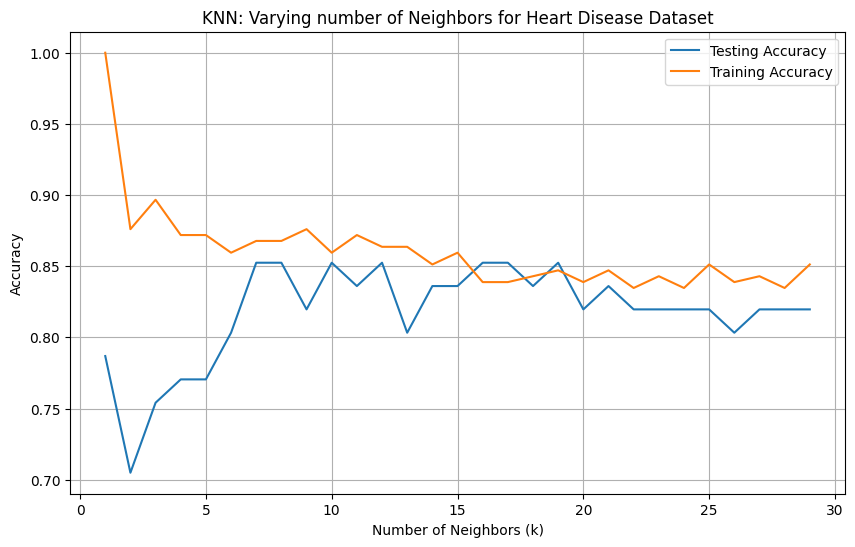

Optimal k value for Heart Disease dataset: 7
Maximum test accuracy for optimal k: 0.8525


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

neighbors_heart = np.arange(1, 30) # Test k from 1 to 29
train_accuracy_heart = np.empty(len(neighbors_heart))
test_accuracy_heart = np.empty(len(neighbors_heart))

# Loop over K values
for i, k in enumerate(neighbors_heart):
    # Setup a KNN Classifier with k neighbors
    knn_heart = KNeighborsClassifier(n_neighbors=k)

    # Fit the model on scaled training data
    knn_heart.fit(X_train_scaled_heart, y_train_heart)

    # Compute accuracy on the scaled training set
    train_accuracy_heart[i] = knn_heart.score(X_train_scaled_heart, y_train_heart)

    # Compute accuracy on the scaled test set
    test_accuracy_heart[i] = knn_heart.score(X_test_scaled_heart, y_test_heart)

# Plotting the train and test accuracies for different k values
plt.figure(figsize=(10, 6))
plt.title('KNN: Varying number of Neighbors for Heart Disease Dataset')
plt.plot(neighbors_heart, test_accuracy_heart, label='Testing Accuracy')
plt.plot(neighbors_heart, train_accuracy_heart, label='Training Accuracy')
plt.legend()
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Find the optimal k based on test accuracy
optimal_k_index_heart = np.argmax(test_accuracy_heart)
optimal_k_heart = neighbors_heart[optimal_k_index_heart]
max_test_accuracy_heart = test_accuracy_heart[optimal_k_index_heart]

print(f"Optimal k value for Heart Disease dataset: {optimal_k_heart}")
print(f"Maximum test accuracy for optimal k: {max_test_accuracy_heart:.4f}")

In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

# 1. Initialize KNN classifier with the optimal k value for the heart disease dataset
knn_optimal_heart = KNeighborsClassifier(n_neighbors=optimal_k_heart)

# 2. Train the model on the scaled training data
knn_optimal_heart.fit(X_train_scaled_heart, y_train_heart)

# 3. Make predictions on the scaled test set
y_pred_heart = knn_optimal_heart.predict(X_test_scaled_heart)

# 4. Calculate accuracy score
accuracy_heart = accuracy_score(y_test_heart, y_pred_heart)
print(f"Accuracy Score on Test Data (Heart Disease): {accuracy_heart:.4f}")

# 5. Display confusion matrix
print("\nConfusion Matrix (Heart Disease):")
cm_heart = confusion_matrix(y_test_heart, y_pred_heart)
display(pd.DataFrame(cm_heart, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# 6. Display classification report
print("\nClassification Report (Heart Disease):")
print(classification_report(y_test_heart, y_pred_heart))

Accuracy Score on Test Data (Heart Disease): 0.8525

Confusion Matrix (Heart Disease):


,Predicted 0,Predicted 1
Actual 0,22,6
Actual 1,3,30



Classification Report (Heart Disease):
              precision    recall  f1-score   support

           0       0.88      0.79      0.83        28
           1       0.83      0.91      0.87        33

    accuracy                           0.85        61
   macro avg       0.86      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

